# Imports and Reading data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

In [2]:
df = pd.read_csv('STO-const_decay.csv')

# Data understanding

In [3]:
df.shape

# 10000 rows and 5 columns as expected

(10000, 5)

In [4]:
df.head(5)

# I realize I wrongly named the forth column "y". It should have been "converged", but it doesn't really matter.

,optimizer_gain,dither_amplitude,dither_frequency,converged,convergence_time
0,0.001795,0.409215,0.762317,0,NaN
1,0.001567,0.457554,0.652944,0,NaN
2,0.082227,0.146464,0.618753,0,NaN
3,0.087334,0.482795,0.463045,0,NaN
4,0.039862,0.479012,0.594150,1,11.82


In [5]:
df.dtypes

optimizer_gain      float64
dither_amplitude    float64
dither_frequency    float64
converged             int64
convergence_time    float64
dtype: object

# Data preparation

In [6]:
df.isna().sum()

# only the convergence_time has duplicated values(7464) so we do not need to drop any rows

optimizer_gain         0
dither_amplitude       0
dither_frequency       0
converged              0
convergence_time    2843
dtype: int64

# Feature understanding

Text(0, 0.5, 'Counts')

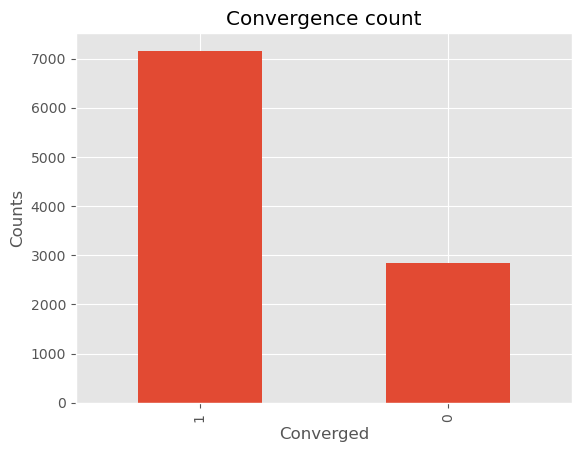

In [8]:
cv = df['converged'].value_counts().head(10).plot(kind = 'bar', title = 'Convergence count')

cv.set_xlabel('Converged')
cv.set_ylabel('Counts')

# Only about one-forth of the values converged

Text(0, 0.5, 'Frequency')

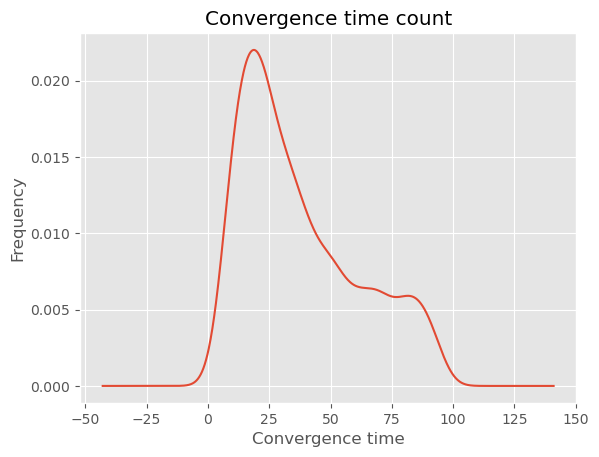

In [ ]:
ct = df['convergence_time'].plot(kind = 'kde',
                title = 'Convergence time count')
ct.set_xlabel('Convergence time')
ct.set_ylabel('Frequency')

# The peak of the graph is at time < 25 (probably around 20), which is not really bad considering the goal is to have convergence_time < 10

In [ ]:
sum(df['convergence_time'] < 10)

# There are 1560 out of 10000 combinations that has the convergence_time < 10, which is extremely good

1560

# Feature relationships

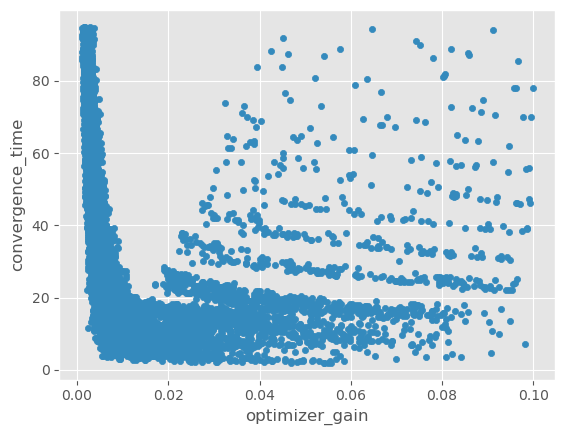

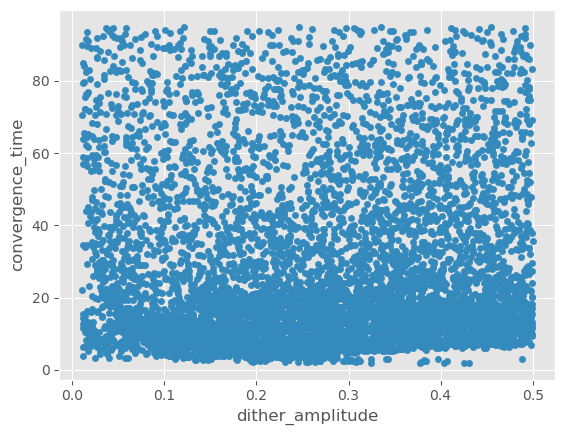

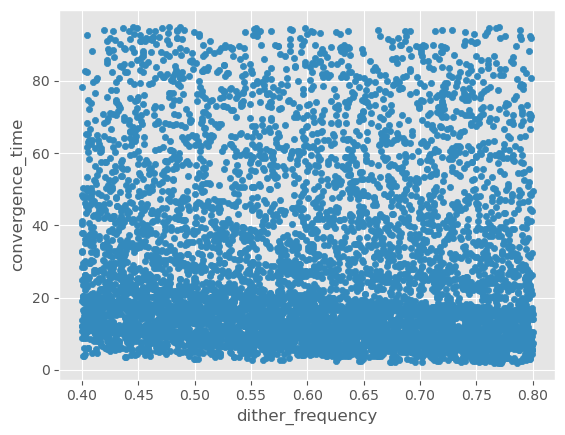

In [10]:
for i in range (df.shape[1] - 2):
    df.plot(kind = 'scatter',
            x = i,
            y = 'convergence_time')
    plt.show()

# As I already achived 40 seconds in my code, we should only look at time <= 40 as the data is quite overwhelming 

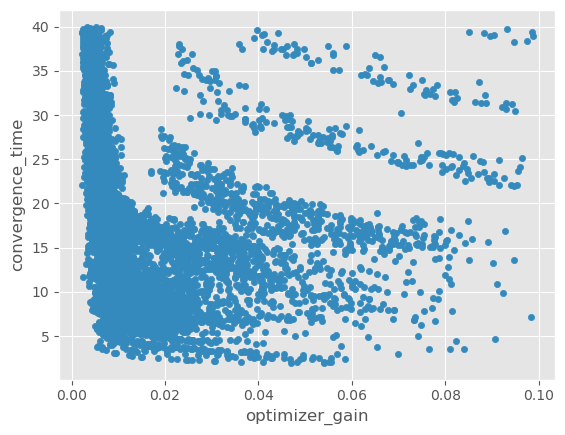

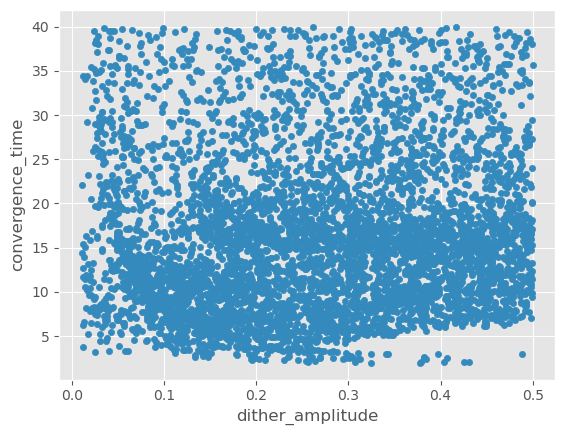

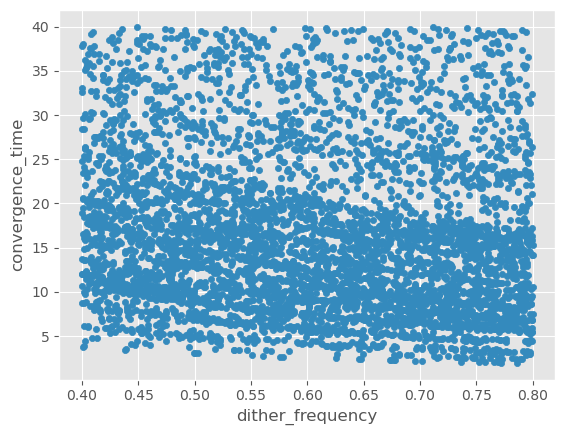

In [13]:
dfcut = df[df['convergence_time'] < 40]
for i in range (dfcut.shape[1] - 2):
    dfcut.plot(kind = 'scatter',
            x = i,
            y = 'convergence_time')
    plt.show()
# It seems like optimizer gain and dither frequency have inverse relationships while dither amplitude has a direct relationship (which is not very clear) with convergence time

In [11]:
sns.pairplot(dfcut,
             vars = ['optimizer_gain','dither_amplitude','dither_frequency', 'convergence_time'])
plt.show()

# Gain and frequency have a direct relationship which makes sense as they both have inverse relationships with convergence time
# The relationships between amplitude and other variables are not very clear

NameError: name 'dfcut' is not defined

<Axes: >

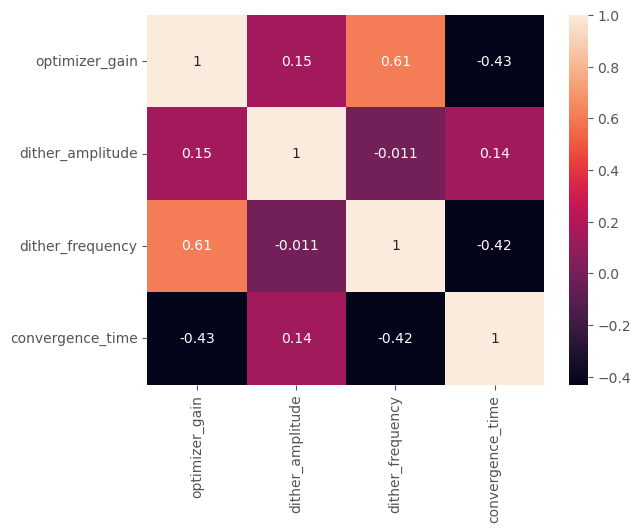

In [ ]:
sns.heatmap(dfcut.drop(columns = 'y').corr(), annot = True)

# The relations are expected

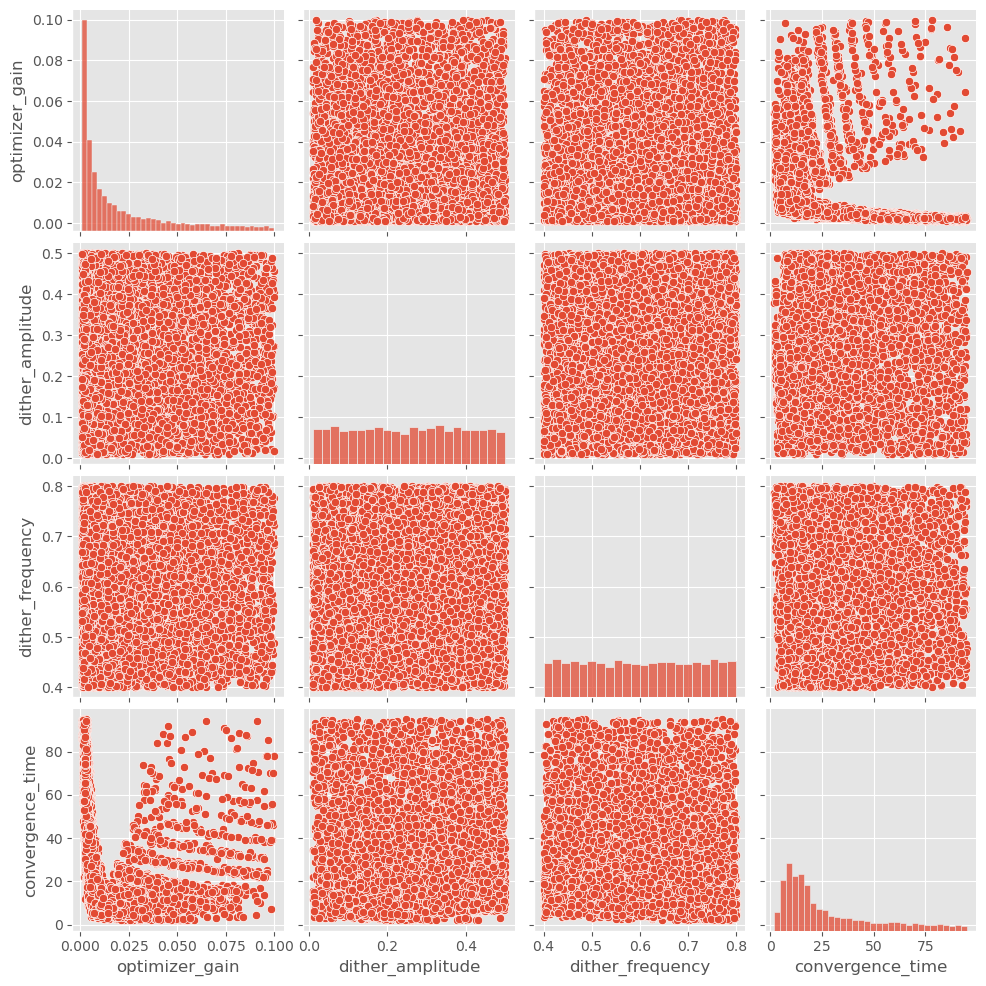

In [12]:
sns.pairplot(df,
             vars = ['optimizer_gain','dither_amplitude','dither_frequency', 'convergence_time'])
plt.show()

# We cannot see very clearly the relationship between gain and frequency anymore

<Axes: >

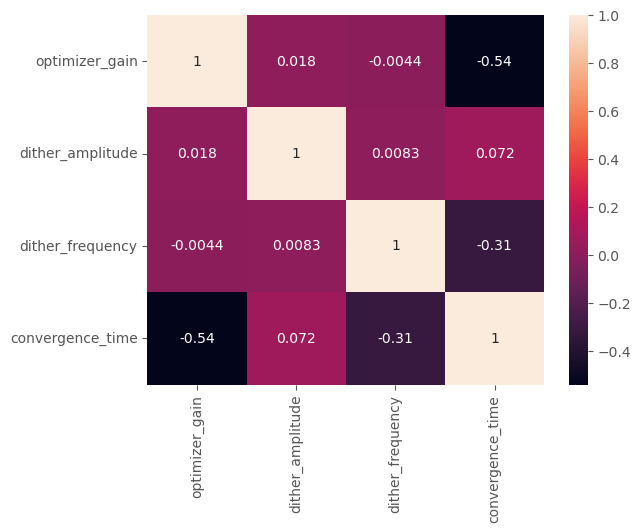

In [ ]:
sns.heatmap(df.drop(columns = 'y').corr(), annot = True)

# The relationship between gain and convergence time is even stronger
# The relationships between frequency and gain/convergence time significantly decreases


# Modelling: Classification

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score



In [ ]:
# Create sets 1 for model 1

X11 = df.drop(columns=['convergence_time', 'y'])
y11 = df['y']

# Get 60% of the dataset as the training set. Put the remaining 40% in temporary variables: x_ and y_.
X_train11, X_, y_train11, y_ = train_test_split(X11, y11, test_size=0.40, random_state=1)

# Split the 40% subset above into two: one half for cross validation and the other for the test set
X_cv11, X_test11, y_cv11, y_test11 = train_test_split(X_, y_, test_size=0.50, random_state=1)

# Delete temporary variables
del X_, y_

In [ ]:
# Create model 1 for set 1
model11 = Sequential(
    [
        Dense(32, activation='relu', name="L1"),
        Dense(16, activation='relu', name="L2"),
        Dense(1, activation = 'linear', name = "L3")  
    ]
)

Epoch 1/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.5743 - val_loss: 0.5782
Epoch 2/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5630 - val_loss: 0.5592
Epoch 3/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5572 - val_loss: 0.5560
Epoch 4/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5468 - val_loss: 0.5453
Epoch 5/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5281 - val_loss: 0.5007
Epoch 6/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4932 - val_loss: 0.4786
Epoch 7/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4569 - val_loss: 0.4324
Epoch 8/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4232 - val_loss: 0.4895
Epoch 9/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4124 - val_loss: 0.4198
Epoch 10/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4005 - val_loss: 0.3982
Epoch 11/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3897 - val_loss: 0.3803
Epoch 12/200
188/188 ━━━━━━━━━━━━━━━━━━━━

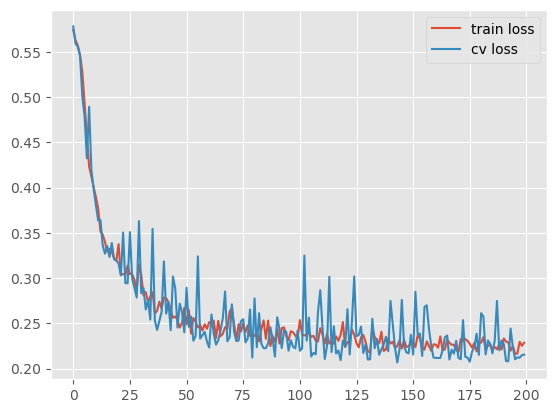

In [ ]:
# Train model 1 with sets 1

model11.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.01),
)
history11 = model11.fit(X_train11, 
                     y_train11, 
                     epochs=200, 
                     validation_data=(X_cv11, y_cv11))
plt.plot(history11.history['loss'], label='train loss')
plt.plot(history11.history['val_loss'], label='cv loss')
plt.legend()
plt.show()

In [ ]:
logits11 = model11.predict(X_cv11)
probs11 = tf.sigmoid(logits11).numpy() # convert logit to probability
y_pred11 = (probs11 > 0.5).astype(int).flatten() # threshold at 0.5, flatten to 1D
accuracy11 = accuracy_score(y_cv11, y_pred11)
print(f"CV accuracy: {accuracy11:.3f}")

# ~90% accuracy. Nice!

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
CV accuracy: 0.897


In [ ]:
print(confusion_matrix(y_cv11, y_pred11))
print(classification_report(y_cv11, y_pred11))

# The precision for "1" is significantly lower than "0", only 0.78 compared to 0.96

[[1370  121]
 [  85  424]]
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      1491
           1       0.78      0.83      0.80       509

    accuracy                           0.90      2000
   macro avg       0.86      0.88      0.87      2000
weighted avg       0.90      0.90      0.90      2000



In [ ]:
train_logits11 = model11.predict(X_train11)
train_probs11 = tf.sigmoid(train_logits11).numpy()
train_pred11 = (train_probs11 > 0.5).astype(int).flatten()
train_acc11 = accuracy_score(y_train11, train_pred11)
print(f"Train accuracy: {train_acc11:.3f}")

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Train accuracy: 0.900


~90% is nice but since this is a simple model, I expect it to have 95+%. 
Since Jcv and Jtrain are approximately the same, the model is very likely underfitting
Based on the difference in precision and recall, I assume that the model is drawing the borderline cutting into the area of "0", which furthermore makes it likely to be underfitting. 

In [ ]:
# Adding more features
df['log10gain'] = np.log10(df['optimizer_gain'])
df['sinfre'] = np.sin(df['dither_frequency'])
df['product'] = df['optimizer_gain'] * df['dither_amplitude'] * df['sinfre']

In [ ]:
# Create set 2 for model 1

X12 = df.drop(columns=['convergence_time', 'y'])
y12 = df['y']

# Get 60% of the dataset as the training set. Put the remaining 40% in temporary variables: x_ and y_.
X_train12, X_, y_train12, y_ = train_test_split(X12, y12, test_size=0.40, random_state=1)

# Split the 40% subset above into two: one half for cross validation and the other for the test set
X_cv12, X_test12, y_cv12, y_test12 = train_test_split(X_, y_, test_size=0.50, random_state=1)

# Delete temporary variables
del X_, y_

In [ ]:
# Create model 1 for set 2
model12 = Sequential(
    [
        Dense(32, activation='relu', name="L1"),
        Dense(16, activation='relu', name="L2"),
        Dense(1, activation = 'linear', name = "L3")  
    ]
)

Epoch 1/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.4908 - val_loss: 0.4365
Epoch 2/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4000 - val_loss: 0.3845
Epoch 3/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3633 - val_loss: 0.3452
Epoch 4/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3361 - val_loss: 0.3230
Epoch 5/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3158 - val_loss: 0.2956
Epoch 6/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3149 - val_loss: 0.2935
Epoch 7/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2945 - val_loss: 0.3308
Epoch 8/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2827 - val_loss: 0.2931
Epoch 9/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2876 - val_loss: 0.2604
Epoch 10/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2728 - val_loss: 0.2750
Epoch 11/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2736 - val_loss: 0.2510
Epoch 12/200
188/188 ━━━━━━━━━━━━━━━━━━━

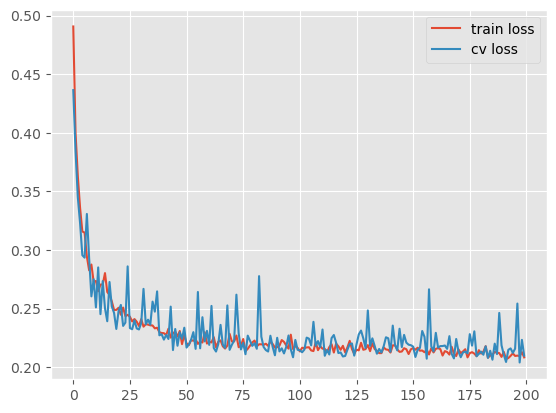

In [ ]:
# Train model 1 with set 2

model12.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.01),
)
history12 = model12.fit(X_train12, 
                     y_train12, 
                     epochs=200, 
                     validation_data=(X_cv12, y_cv12))
plt.plot(history12.history['loss'], label='train loss')
plt.plot(history12.history['val_loss'], label='cv loss')
plt.legend()
plt.show()

In [ ]:
logits12 = model12.predict(X_cv12)
probs12 = tf.sigmoid(logits12).numpy() # convert logit to probability
y_pred12 = (probs12 > 0.5).astype(int).flatten() # threshold at 0.5, flatten to 1D
accuracy12 = accuracy_score(y_cv12, y_pred12)
print(f"CV accuracy: {accuracy12:.3f}")


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
CV accuracy: 0.906


In [ ]:
print(confusion_matrix(y_cv12, y_pred12))
print(classification_report(y_cv12, y_pred12))

[[1350  141]
 [  46  463]]
              precision    recall  f1-score   support

           0       0.97      0.91      0.94      1491
           1       0.77      0.91      0.83       509

    accuracy                           0.91      2000
   macro avg       0.87      0.91      0.88      2000
weighted avg       0.92      0.91      0.91      2000



In [ ]:
train_logits12 = model12.predict(X_train12)
train_probs12 = tf.sigmoid(train_logits12).numpy()
train_pred12 = (train_probs12 > 0.5).astype(int).flatten()
train_acc12 = accuracy_score(y_train12, train_pred12)
print(f"Train accuracy: {train_acc12:.3f}")

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Train accuracy: 0.909


Since the accuracy does not improve even when I add more features, I assume it is due the lack of layers/units that is keeping the model from giving more accurate results

In [ ]:
# Create sets 1 for model 2

X21 = df.drop(columns=['convergence_time', 'y'])
y21 = df['y']

# Get 60% of the dataset as the training set. Put the remaining 40% in temporary variables: x_ and y_.
X_train21, X_, y_train21, y_ = train_test_split(X21, y21, test_size=0.40, random_state=1)

# Split the 40% subset above into two: one half for cross validation and the other for the test set
X_cv21, X_test21, y_cv21, y_test21 = train_test_split(X_, y_, test_size=0.50, random_state=1)

# Delete temporary variables
del X_, y_

In [ ]:
# Create model 2 for set 1
model21 = Sequential(
    [
        Dense(64, activation='relu', name="L1"),
        Dense(32, activation='relu', name="L2"),
        Dense(16, activation='relu', name="L3"),
        Dense(1, activation = 'linear', name = "L4")  
    ]
)

Epoch 1/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.4469 - val_loss: 0.3628
Epoch 2/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3129 - val_loss: 0.2925
Epoch 3/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2707 - val_loss: 0.3099
Epoch 4/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2649 - val_loss: 0.2687
Epoch 5/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2551 - val_loss: 0.2495
Epoch 6/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2548 - val_loss: 0.2381
Epoch 7/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2573 - val_loss: 0.2517
Epoch 8/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2474 - val_loss: 0.2552
Epoch 9/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.2503 - val_loss: 0.2312
Epoch 10/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2360 - val_loss: 0.2454
Epoch 11/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2563 - val_loss: 0.2406
Epoch 12/200
188/188 ━━━━━━━━━━━━━━━━━━━━

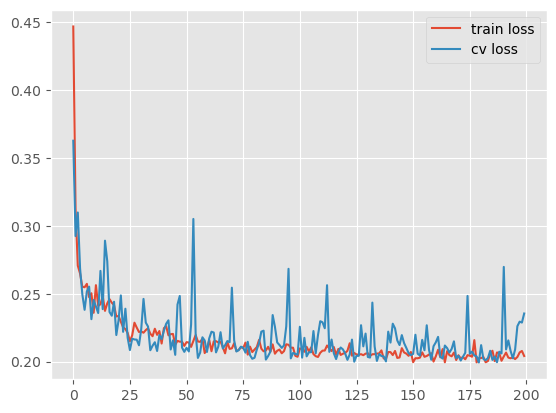

In [ ]:
# Train model 2 with set 1

model21.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.01),
)
history21 = model21.fit(X_train21, 
                     y_train21, 
                     epochs=200, 
                     validation_data=(X_cv21, y_cv21))
plt.plot(history21.history['loss'], label='train loss')
plt.plot(history21.history['val_loss'], label='cv loss')
plt.legend()
plt.show()

In [ ]:
logits21 = model21.predict(X_cv21)
probs21 = tf.sigmoid(logits21).numpy() # convert logit to probability
y_pred21 = (probs21 > 0.5).astype(int).flatten() # threshold at 0.5, flatten to 1D
accuracy21 = accuracy_score(y_cv21, y_pred21)
print(f"CV accuracy: {accuracy21:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
CV accuracy: 0.891


In [ ]:
print(confusion_matrix(y_cv21, y_pred21))
print(classification_report(y_cv21, y_pred21))


[[1343  148]
 [  69  440]]
              precision    recall  f1-score   support

           0       0.95      0.90      0.93      1491
           1       0.75      0.86      0.80       509

    accuracy                           0.89      2000
   macro avg       0.85      0.88      0.86      2000
weighted avg       0.90      0.89      0.89      2000



Adding more feautures or layers/units does not improve the performance. The problem, therefore, might be in the data itself.

In [ ]:
# Find where the false positives are
false_positive11 = (y_pred11 == 1) & (y_cv11 == 0)
X_cv11_df = pd.DataFrame(X_cv11, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv11_df[false_positive11].describe())

false_positive12 = (y_pred12 == 1) & (y_cv12 == 0)
X_cv12_df = pd.DataFrame(X_cv12, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv12_df[false_positive12].describe())

false_positive21 = (y_pred21 == 1) & (y_cv21 == 0)
X_cv21_df = pd.DataFrame(X_cv21, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv21_df[false_positive21].describe())

       optimizer_gain  dither_amplitude  dither_frequency
count      121.000000        121.000000        121.000000
mean         0.002777          0.212188          0.325504
std          0.002073          0.142343          0.132263
min          0.000358          0.011318          0.014197
25%          0.001289          0.092329          0.237427
50%          0.002062          0.166176          0.359420
75%          0.003942          0.341579          0.437106
max          0.009239          0.494990          0.497523
       optimizer_gain  dither_amplitude  dither_frequency
count      141.000000        141.000000        141.000000
mean         0.002400          0.224763          0.292870
std          0.002160          0.146496          0.143557
min          0.000109          0.011318          0.012403
25%          0.000757          0.094607          0.179111
50%          0.001586          0.189168          0.304986
75%          0.003131          0.361554          0.419667
max          0

In [ ]:
fp11 = X_cv11_df[false_positive11]
fp12 = X_cv12_df[false_positive12]
fp21 = X_cv21_df[false_positive21]

fp = pd.concat([fp11, fp12, fp21], ignore_index=True)
print(fp.describe())

       optimizer_gain  dither_amplitude  dither_frequency
count      410.000000        410.000000        410.000000
mean         0.002782          0.216156          0.295286
std          0.002222          0.142934          0.143479
min          0.000109          0.011318          0.011601
25%          0.001181          0.092329          0.180443
50%          0.002062          0.182717          0.318782
75%          0.004093          0.355397          0.420383
max          0.009765          0.495820          0.497523


    n_D_decay_rate = 1/(1.71 + (rand()-0.5)*0.2); % +- 0.1
    n_T_decay_rate = 1/(1.66 + (rand()-0.5)*0.2); % +- 0.1

I just realized my simulation code has the above 2 lines, which may be accountable for the errors.

I am going to examine the combinations that results in convergence time < 10 to create a new dataset with constant decay rate

In [ ]:
df10 = df[df['convergence_time'] < 10].drop(columns=['product','y', 'sinfre']).reset_index(drop = True)


print(df10)

     optimizer_gain  dither_amplitude  dither_frequency  convergence_time  \
0          0.004261          0.084825          0.381397              6.59   
1          0.004848          0.142388          0.447890              9.62   
2          0.002755          0.136689          0.269069              8.63   
3          0.007617          0.480379          0.402806              9.85   
4          0.003385          0.298826          0.309669              9.54   
..              ...               ...               ...               ...   
173        0.009062          0.360631          0.449004              5.72   
174        0.002358          0.244302          0.247044              9.92   
175        0.007071          0.109942          0.448894              3.43   
176        0.004717          0.351930          0.354646              9.23   
177        0.004713          0.115314          0.409425              6.31   

     log10gain  
0    -2.370475  
1    -2.314425  
2    -2.559870  
3    -2

In [ ]:
df10.to_csv('convergencetime_less_10_randomdecayrate')